## Índice

1. Importação de Bibliotecas
2. Carregamento dos Dados
3. Compreensão do Problema e Definição do Alvo Binário
4. Análise Exploratória de Dados (EDA)
5. Pré-processamento (faltantes, normalização, feature engineering, split)
6. Desenvolvimento dos Modelos
7. Avaliação dos Modelos
8. Interpretação dos Resultados
9. Conclusão

## 1 | Importação de Bibliotecas

In [1]:
# --- Manipulação de dados ---
import numpy as np                      # operações numéricas e arrays
import pandas as pd                      # manipulação de dataframes

# --- Visualização ---
import matplotlib.pyplot as plt          # gráficos estáticos
import seaborn as sns                    # gráficos estatísticos sobre matplotlib

# --- Pré-processamento e split ---
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler   # padronização (z-score) das variáveis numéricas

# --- Modelos de classificação ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# --- Métricas de avaliação ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")        # oculta warnings para deixar a saída mais limpa

# Configurações visuais
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
PALETTE = ["#990012", "#DEB078"]         # paleta reaproveitada do notebook original
RANDOM_STATE = 12                        # random_state fixo para reprodutibilidade em todo o notebook


## 2 | Carregamento dos Dados

In [2]:
# URL pública (mirror no GitHub) do Wine Quality Dataset (UCI / Kaggle) - variante tinto
DATA_URL = "https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/master/winequality-red.csv"

# Leitura do CSV (separador ';' é o padrão do dataset original da UCI)
df = pd.read_csv(DATA_URL, sep=";")

# Visualização das 5 primeiras linhas para conferência
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Dimensões do dataset: (linhas, colunas)
print("Formato do dataset:", df.shape)

# Tipos de dados de cada coluna
print("\nTipos de dados:")
print(df.dtypes)


Formato do dataset: (1599, 12)

Tipos de dados:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


## 3 | Compreensão do Problema

**Contexto de negócio:** a indústria vitivinícola tem grande relevância econômica e cultural em diversos países. Tradicionalmente, a qualidade de um vinho é avaliada por especialistas por meio de análise sensorial (aroma, sabor, acidez, equilíbrio) — um processo **subjetivo, demorado e dependente da experiência do avaliador**. Com o avanço da ciência de dados, é possível usar as características **físico-químicas** medidas durante a produção (acidez, teor alcoólico, densidade, dióxido de enxofre, etc.) para prever a qualidade final do vinho, apoiando enólogos e produtores na tomada de decisão e contribuindo para a padronização da qualidade ao longo do processo produtivo.

**Variável alvo:** `quality`, nota de qualidade atribuída por especialistas (escala de 0 a 10). Neste dataset (vinho tinto), os valores observados variam de 3 a 8.

**Transformação em classificação binária** (conforme exigido pelo desafio):
- `1` → Vinho de **Alta Qualidade** (nota ≥ 7)
- `0` → Vinho de **Baixa/Média Qualidade** (nota < 7)

In [4]:
# Cria a variável alvo binária a partir da nota de qualidade original
df["quality_binary"] = (df["quality"] >= 7).astype(int)

# Mantém a coluna 'quality' original apenas para referência/EDA, mas o alvo de modelagem é 'quality_binary'
print(df[["quality", "quality_binary"]].head(10))


   quality  quality_binary
0        5               0
1        5               0
2        5               0
3        6               0
4        5               0
5        5               0
6        5               0
7        7               1
8        7               1
9        5               0


## 4 | Análise Exploratória de Dados (EDA)

### 4.1 | Distribuição das Variáveis Numéricas

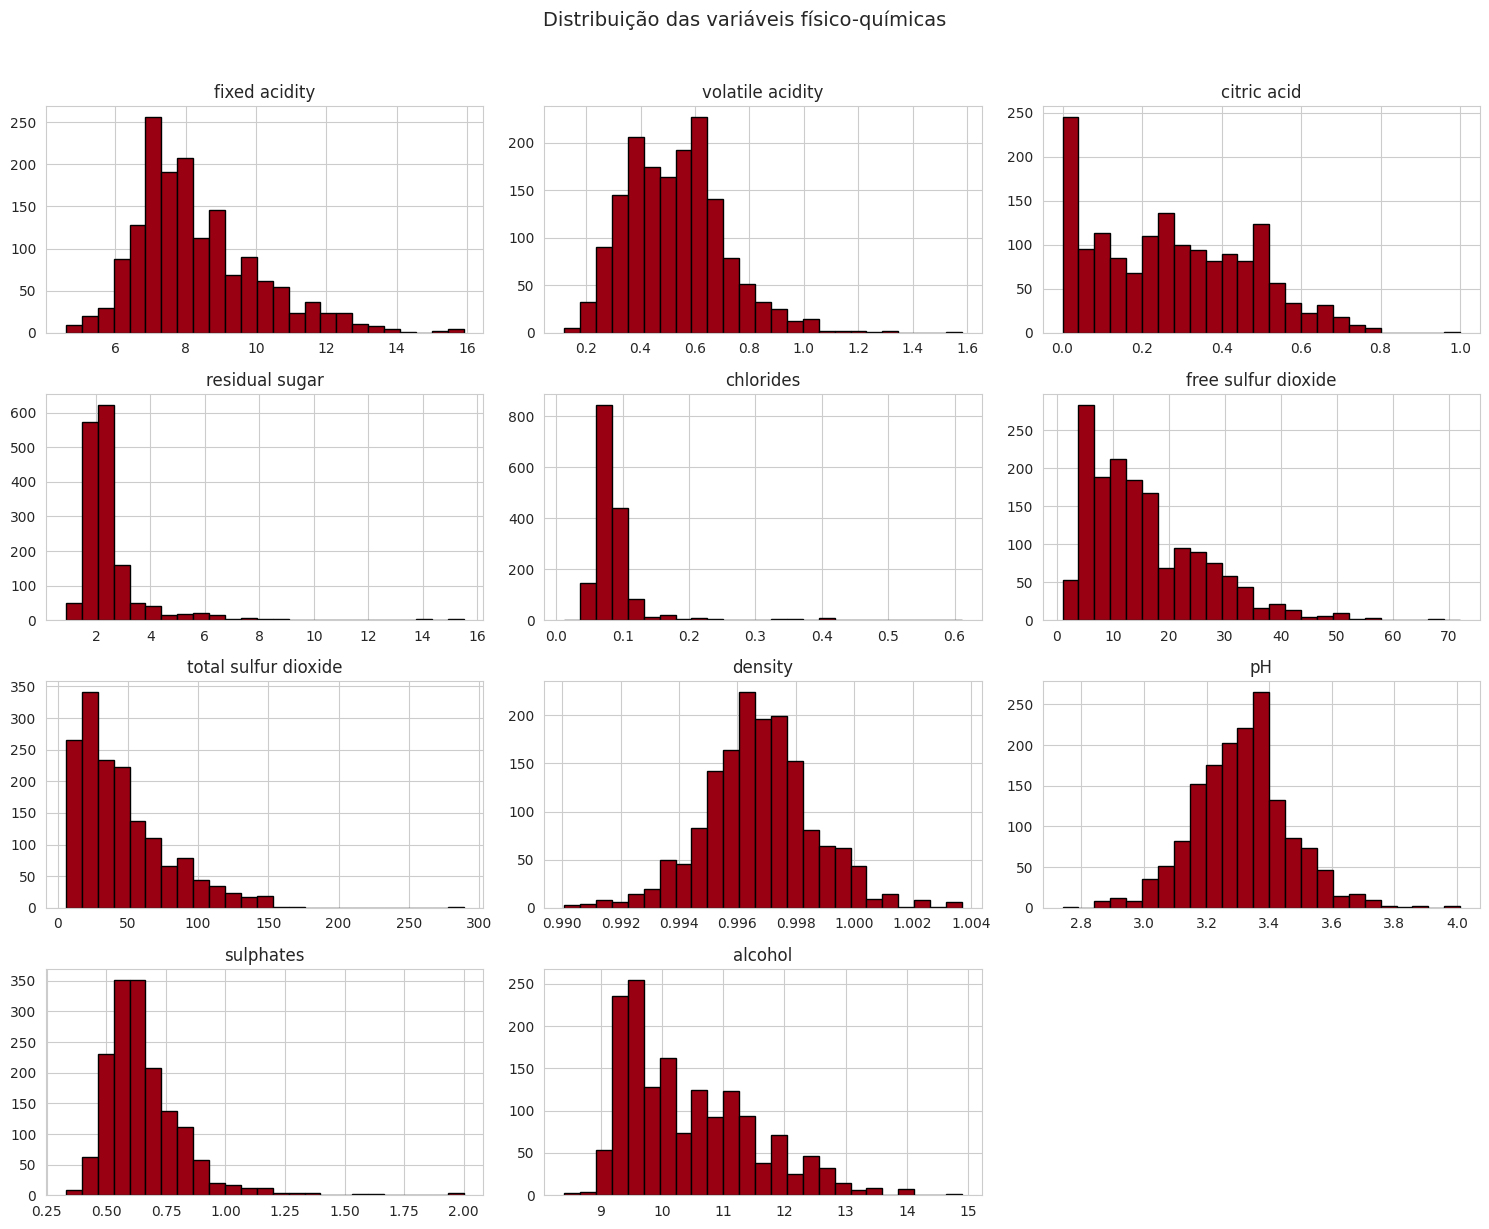

In [5]:
# Lista das variáveis físico-químicas (features contínuas)
features = [c for c in df.columns if c not in ["quality", "quality_binary"]]

# Histogramas de cada variável para observar forma da distribuição (assimetria, caudas, etc.)
df[features].hist(bins=25, figsize=(15, 12), color=PALETTE[0], edgecolor="black")
plt.suptitle("Distribuição das variáveis físico-químicas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 4.2 | Detecção de Outliers (Método IQR)

In [6]:
# Calcula quartis e IQR (intervalo interquartil) para cada feature
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Para cada coluna, conta quantos valores estão fora dos limites (outliers)
print("Contagem de outliers por variável (método IQR):\n")
for col in features:
    outliers = df[(df[col] < limite_inferior[col]) | (df[col] > limite_superior[col])]
    pct = 100 * len(outliers) / len(df)
    print(f"{col:<25} -> {len(outliers):4d} outliers  ({pct:.1f}% do total)  | skew = {df[col].skew():.2f}")


Contagem de outliers por variável (método IQR):

fixed acidity             ->   49 outliers  (3.1% do total)  | skew = 0.98
volatile acidity          ->   19 outliers  (1.2% do total)  | skew = 0.67
citric acid               ->    1 outliers  (0.1% do total)  | skew = 0.32
residual sugar            ->  155 outliers  (9.7% do total)  | skew = 4.54
chlorides                 ->  112 outliers  (7.0% do total)  | skew = 5.68
free sulfur dioxide       ->   30 outliers  (1.9% do total)  | skew = 1.25
total sulfur dioxide      ->   55 outliers  (3.4% do total)  | skew = 1.52
density                   ->   45 outliers  (2.8% do total)  | skew = 0.07
pH                        ->   35 outliers  (2.2% do total)  | skew = 0.19
sulphates                 ->   59 outliers  (3.7% do total)  | skew = 2.43
alcohol                   ->   13 outliers  (0.8% do total)  | skew = 0.86


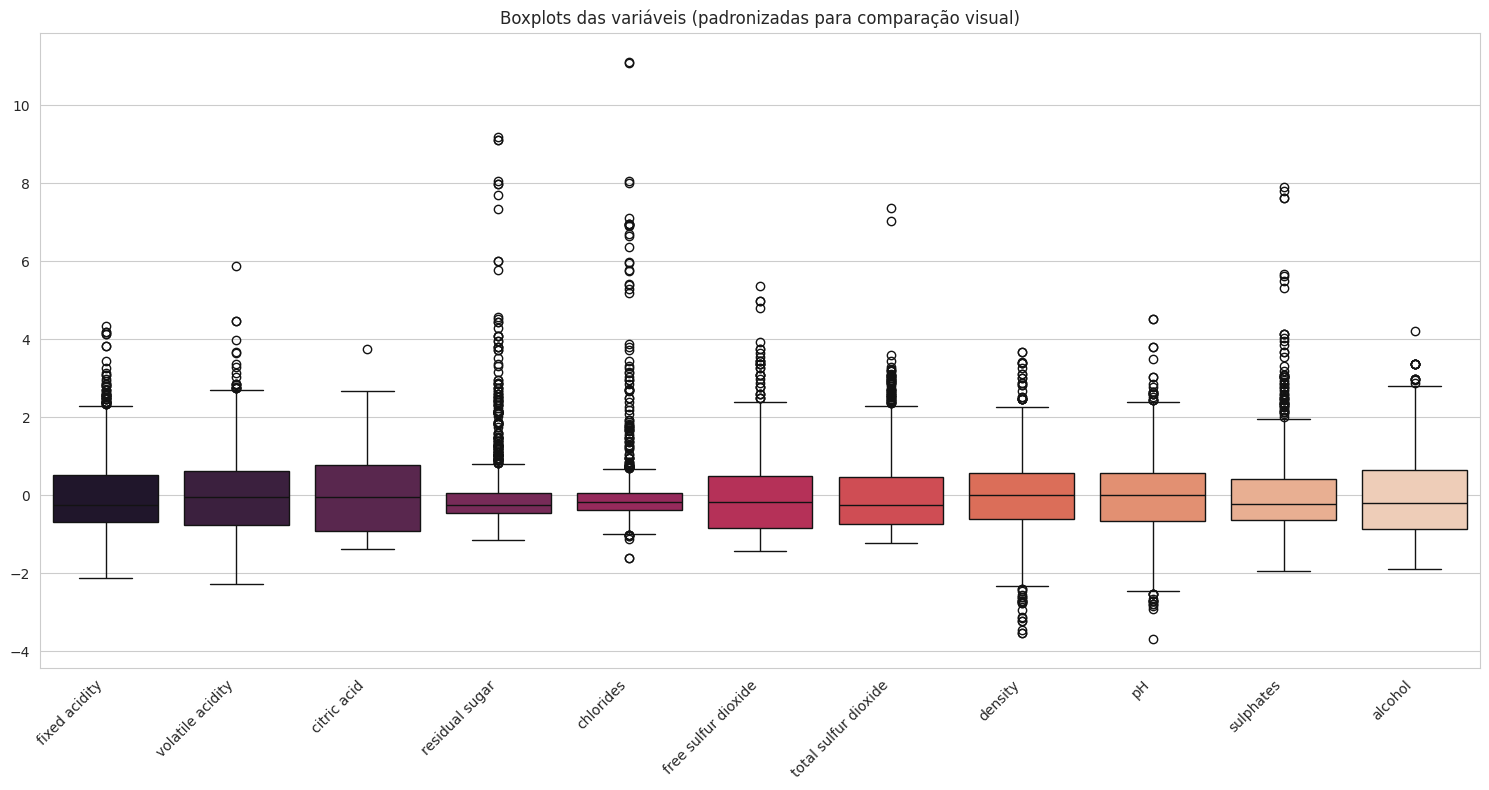

In [7]:
# Boxplots para visualizar outliers de todas as variáveis de uma vez
plt.figure(figsize=(15, 8))
df_norm = (df[features] - df[features].mean()) / df[features].std()   # padroniza só para visualização comparável
sns.boxplot(data=df_norm, palette="rocket")
plt.xticks(rotation=45, ha="right")
plt.title("Boxplots das variáveis (padronizadas para comparação visual)")
plt.tight_layout()
plt.show()


**Insight:** variáveis como `residual sugar`, `chlorides`, `free sulfur dioxide` e `total sulfur dioxide` apresentam número relevante de outliers e assimetria positiva (cauda à direita). Optamos por **não remover** esses outliers, pois em modelos baseados em árvore (Random Forest, Gradient Boosting) eles têm baixo impacto e podem representar vinhos genuinamente atípicos (o que é relevante para o problema de negócio).

### 4.3 | Matriz de Correlação e Relação com a Qualidade

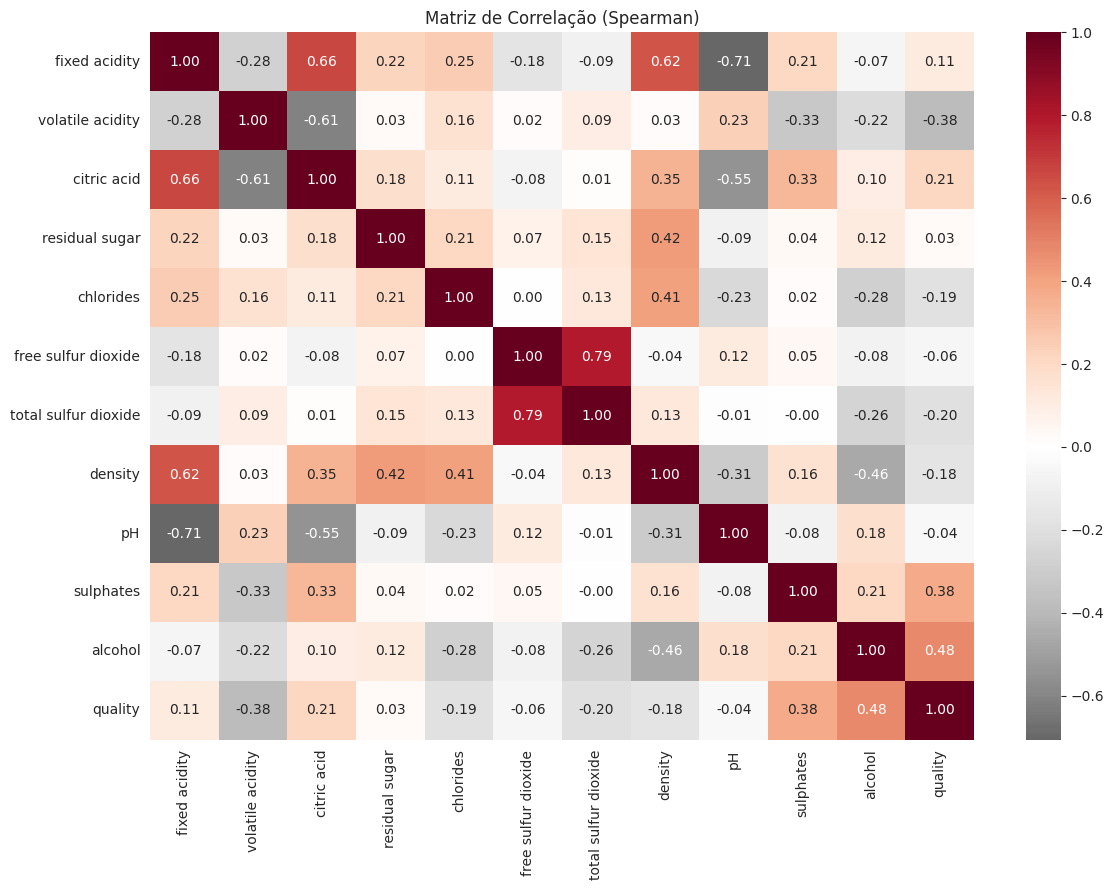

In [8]:
# Matriz de correlação de Spearman (mais adequada que Pearson pois 'quality' é ordinal)
corr = df[features + ["quality"]].corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdGy_r", center=0)
plt.title("Matriz de Correlação (Spearman)")
plt.tight_layout()
plt.show()


In [9]:
# Correlação de cada feature especificamente com 'quality', ordenada por força
corr_quality = corr["quality"].drop("quality").sort_values(key=abs, ascending=False)
print("Correlação (Spearman) de cada variável com 'quality':\n")
print(corr_quality)


Correlação (Spearman) de cada variável com 'quality':

alcohol                 0.478532
volatile acidity       -0.380647
sulphates               0.377060
citric acid             0.213481
total sulfur dioxide   -0.196735
chlorides              -0.189922
density                -0.177074
fixed acidity           0.114084
free sulfur dioxide    -0.056901
pH                     -0.043672
residual sugar          0.032048
Name: quality, dtype: float64


**Justificativa das correlações mais relevantes:**
- `alcohol` tem a correlação positiva mais forte com a qualidade — vinhos com maior teor alcoólico tendem a receber notas mais altas.
- `volatile acidity` tem correlação negativa relevante — excesso de acidez volátil (gosto de vinagre) prejudica a nota.
- `sulphates` e `citric acid` têm correlação positiva moderada, associados a frescor e conservação do vinho.
- `density` e `total sulfur dioxide` mostram correlação negativa fraca a moderada.

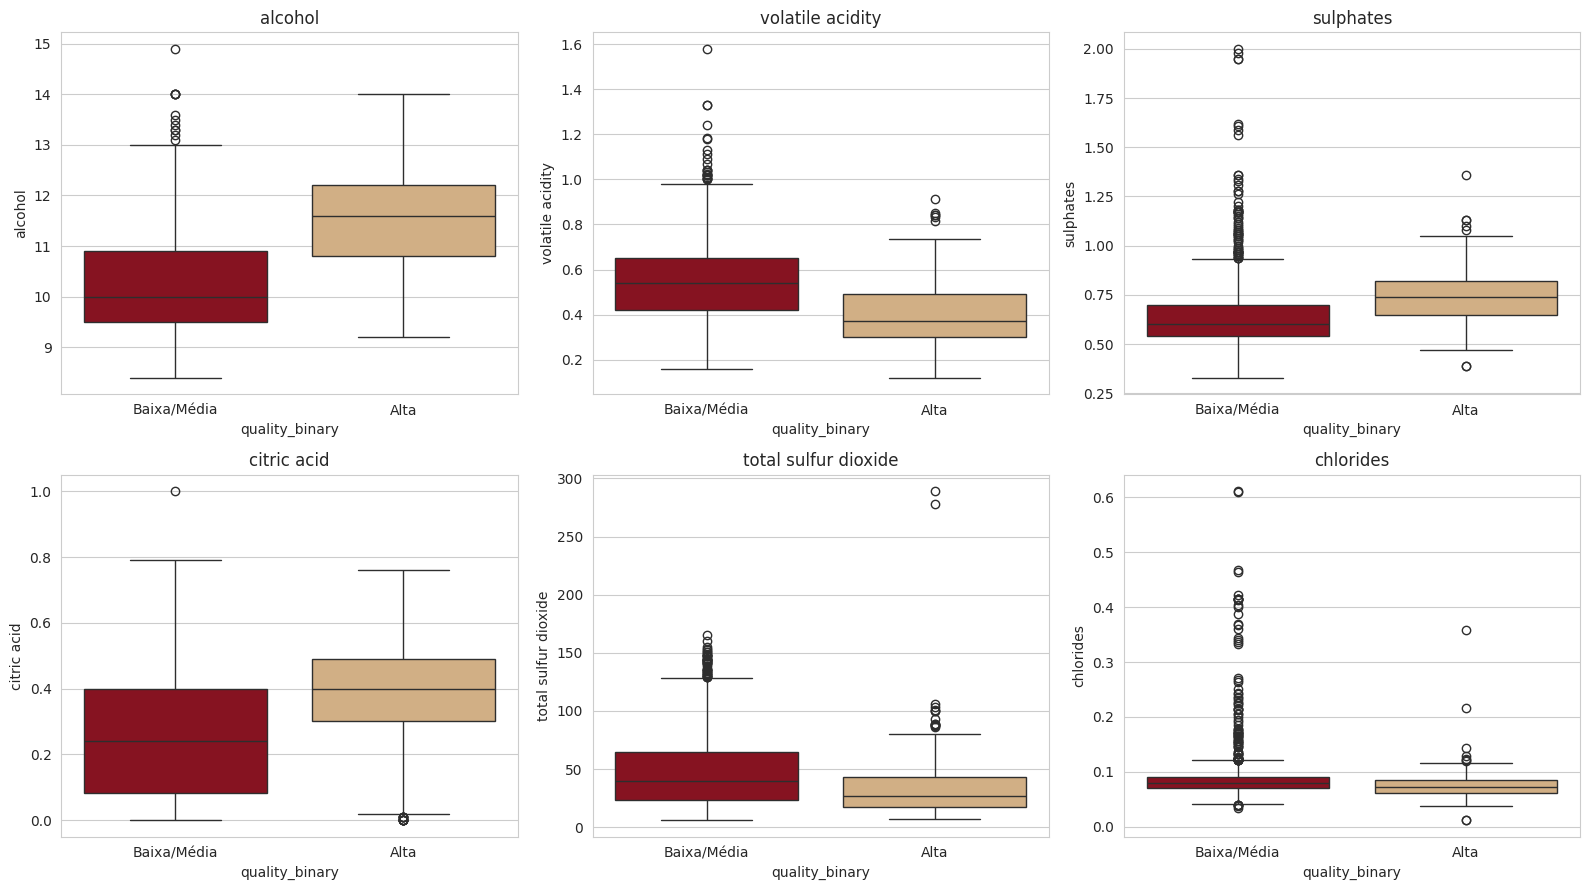

In [10]:
# Boxplots das principais variáveis por classe binária (Alta vs Baixa/Média qualidade)
top_features = corr_quality.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.boxplot(data=df, x="quality_binary", y=col, palette=PALETTE, ax=axes[i])
    axes[i].set_xticklabels(["Baixa/Média", "Alta"])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


**Insight:** vinhos de Alta Qualidade apresentam mediana de `alcohol` e `sulphates` visivelmente mais alta, e mediana de `volatile acidity` mais baixa — consistente com a análise de correlação acima.

### 4.4 | Balanceamento das Classes (Alvo Binário)

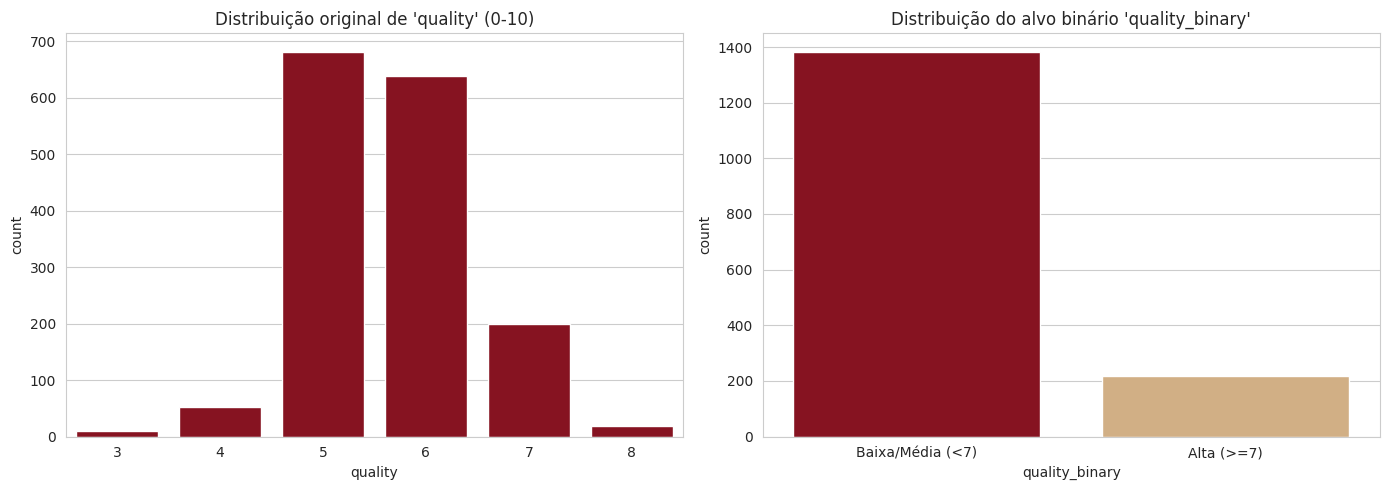

Baixa/Média Qualidade: 86.4%  |  Alta Qualidade: 13.6%


In [11]:
# Distribuição da variável alvo original (multiclasse) vs. o alvo binário criado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="quality", data=df, color=PALETTE[0], ax=axes[0])
axes[0].set_title("Distribuição original de 'quality' (0-10)")

sns.countplot(x="quality_binary", data=df, palette=PALETTE, ax=axes[1])
axes[1].set_xticklabels(["Baixa/Média (<7)", "Alta (>=7)"])
axes[1].set_title("Distribuição do alvo binário 'quality_binary'")

plt.tight_layout()
plt.show()

# Proporção percentual de cada classe binária
prop = df["quality_binary"].value_counts(normalize=True) * 100
print(f"Baixa/Média Qualidade: {prop[0]:.1f}%  |  Alta Qualidade: {prop[1]:.1f}%")


**Insight:** o alvo binário está **desbalanceado** — apenas ~13-14% dos vinhos são classificados como Alta Qualidade. Isso é tratado no pré-processamento/modelagem com `class_weight='balanced'` nos modelos, já que aplicar SMOTE aqui poderia mascarar o comportamento real dos dados de produção.

## 5 | Pré-processamento de Dados

### 5.1 | Valores Faltantes

In [12]:
# Verifica a quantidade de valores nulos por coluna
nulos = df.isna().sum()
print("Valores nulos por coluna:\n", nulos)
print("\nTotal de valores nulos no dataset:", nulos.sum())


Valores nulos por coluna:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_binary          0
dtype: int64

Total de valores nulos no dataset: 0


**Insight:** não há valores faltantes no dataset — nenhum tratamento de imputação é necessário.

### 5.2 | Valores Inconsistentes (Linhas Duplicadas)

In [13]:
# Conta quantas linhas estão completamente duplicadas no dataset
n_duplicadas = df.duplicated().sum()
print(f"Linhas duplicadas encontradas: {n_duplicadas} ({100 * n_duplicadas / len(df):.1f}% do total)")

# Remove as duplicatas, mantendo a primeira ocorrência de cada uma
df = df.drop_duplicates().reset_index(drop=True)

print(f"Formato do dataset após remoção de duplicatas: {df.shape}")


Linhas duplicadas encontradas: 240 (15.0% do total)
Formato do dataset após remoção de duplicatas: (1359, 13)


**Insight:** foram encontradas **240 linhas duplicadas (15% do dataset)** — um volume relevante de inconsistência que, se não tratado, infla artificialmente a importância dessas amostras durante o treinamento e pode distorcer as métricas de validação. Após a remoção, o dataset segue com dados únicos e consistentes.

### 5.3 | Feature Engineering

In [14]:
# Feature 1: acidez total combinada (soma das 3 formas de acidez do vinho)
df["acidity_total"] = df["fixed acidity"] + df["volatile acidity"] + df["citric acid"]

# Feature 2: proporção de SO2 livre em relação ao SO2 total
# (indicador prático usado por enólogos para avaliar eficácia da conservação do vinho)
df["free_sulfur_ratio"] = df["free sulfur dioxide"] / df["total sulfur dioxide"]

# Feature 3: razão entre álcool e densidade
# (o álcool tende a reduzir a densidade do vinho; a razão captura essa interação)
df["alcohol_density_ratio"] = df["alcohol"] / df["density"]

# Atualiza a lista de features para incluir as novas colunas criadas
features = [c for c in df.columns if c not in ["quality", "quality_binary"]]

df[["acidity_total", "free_sulfur_ratio", "alcohol_density_ratio"]].describe()


,acidity_total,free_sulfur_ratio,alcohol_density_ratio
count,1359.000000,1359.000000,1359.000000
mean,9.112406,0.381488,10.467828
std,1.827724,0.154527,1.096793
min,5.270000,0.022727,8.393285
25%,7.820000,0.260252,9.532649
50%,8.730000,0.375000,10.206124
75%,10.070000,0.484360,11.153649
max,17.045000,0.857143,14.935846


### 5.4 | Separação em Treino e Teste (Split Estratificado)

In [15]:
# X = variáveis explicativas | y = variável alvo binária
X = df[features]
y = df["quality_binary"]

# Split 70/30 com estratificação para preservar a proporção de classes (dado o desbalanceamento)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print("Treino:", X_train.shape, " | Teste:", X_test.shape)
print("\nProporção da classe positiva no treino:", round(y_train.mean(), 3))
print("Proporção da classe positiva no teste:  ", round(y_test.mean(), 3))


Treino: (951, 14)  | Teste: (408, 14)

Proporção da classe positiva no treino: 0.136
Proporção da classe positiva no teste:   0.135


### 5.5 | Normalização / Padronização

In [16]:
# Instancia o padronizador (média 0, desvio padrão 1)
scaler = StandardScaler()

# Ajusta o scaler apenas com dados de treino
X_train_scaled = scaler.fit_transform(X_train)

# Aplica a mesma transformação (já ajustada) ao conjunto de teste
X_test_scaled = scaler.transform(X_test)

# Reconverte para DataFrame mantendo os nomes das colunas (facilita interpretação depois)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().loc[["mean", "std"]]   # confirma média ~0 e desvio padrão ~1


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,acidity_total,free_sulfur_ratio,alcohol_density_ratio
mean,-9.152627e-17,1.569022e-16,2.559000e-16,-1.232803e-16,5.136679e-17,-2.755128e-17,-6.537591e-17,4.272876e-14,1.004921e-15,-2.502963e-16,1.459751e-15,-1.120730e-17,2.334854e-16,4.015949e-16
std,1.000526e+00,1.000526e+00,1.000526e+00,1.000526e+00,1.000526e+00,1.000526e+00,1.000526e+00,1.000526e+00,1.000526e+00,1.000526e+00,1.000526e+00,1.000526e+00,1.000526e+00,1.000526e+00


## 6 | Desenvolvimento dos Modelos

In [17]:
# Dicionário com os modelos a serem treinados e comparados
models = {
    "Regressão Logística": LogisticRegression(
        class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", random_state=RANDOM_STATE, n_estimators=300
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE, n_estimators=300
    ),
}


### 6.1 | Validação Cruzada (Treino)

In [18]:
# Validação cruzada estratificada com 5 folds (mantém a proporção de classes em cada fold)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []  # lista para acumular os resultados (substitui o uso de DataFrame.append do original)

for name, model in models.items():
    # Regressão Logística usa dados padronizados; modelos de árvore não precisam, mas não há problema em usar os mesmos dados escalados
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="f1")
    cv_results.append({"Modelo": name, "F1_medio_CV": scores.mean(), "F1_desvio_CV": scores.std()})
    print(f"{name:<22} F1 (CV) = {scores.mean():.3f} (+/- {scores.std():.3f})")

cv_results_df = pd.DataFrame(cv_results)


Regressão Logística    F1 (CV) = 0.513 (+/- 0.057)


Random Forest          F1 (CV) = 0.393 (+/- 0.043)


Gradient Boosting      F1 (CV) = 0.467 (+/- 0.134)


### 6.2 | Treinamento Final e Predição no Conjunto de Teste

In [19]:
# Dicionário para armazenar as predições de cada modelo no conjunto de teste
predictions = {}
probabilities = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)                       # treina o modelo com dados de treino padronizados
    predictions[name] = model.predict(X_test_scaled)          # predição de classe (0 ou 1)
    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]  # probabilidade da classe positiva (para AUC-ROC)
    fitted_models[name] = model                                # guarda o modelo treinado para uso posterior (importância de variáveis)

print("Modelos treinados:", list(fitted_models.keys()))


Modelos treinados: ['Regressão Logística', 'Random Forest', 'Gradient Boosting']


## 7 | Avaliação dos Modelos

In [20]:
# Constrói uma tabela comparativa com as principais métricas de classificação binária
metricas = []
for name in models.keys():
    y_pred = predictions[name]
    y_proba = probabilities[name]
    metricas.append({
        "Modelo": name,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba),
    })

metricas_df = pd.DataFrame(metricas).set_index("Modelo").round(3)
metricas_df.sort_values("F1-Score", ascending=False)


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Regressão Logística,0.772,0.344,0.764,0.475,0.860
Gradient Boosting,0.882,0.606,0.364,0.455,0.860
Random Forest,0.877,0.593,0.291,0.390,0.861


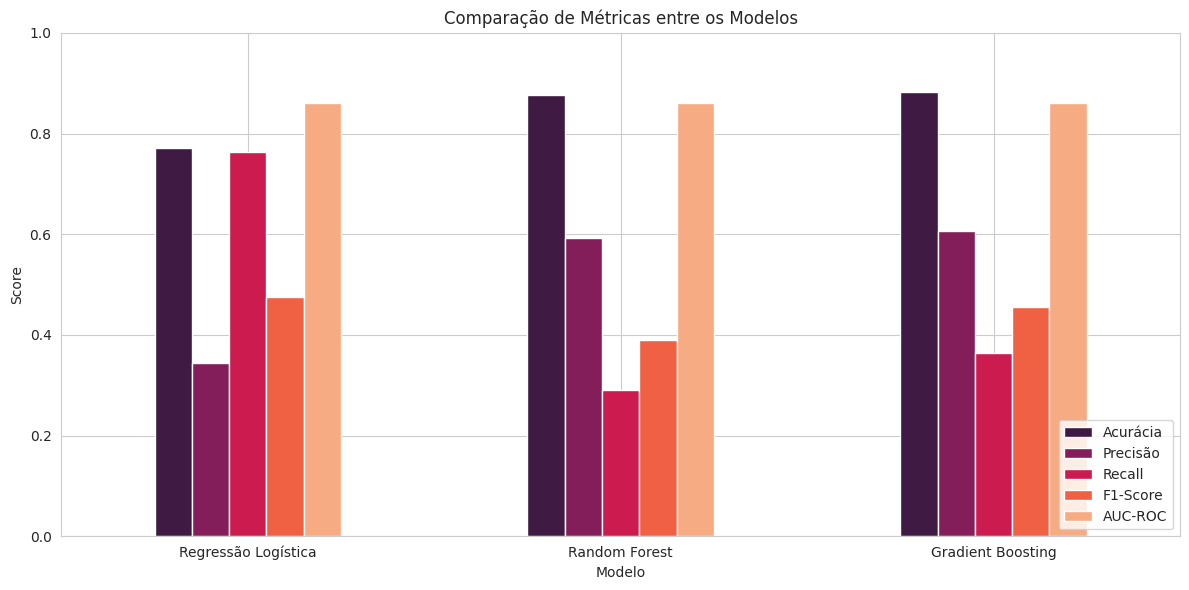

In [21]:
# Gráfico de barras comparando as métricas entre os modelos
metricas_df.plot(kind="bar", figsize=(12, 6), color=sns.color_palette("rocket", 5))
plt.title("Comparação de Métricas entre os Modelos")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 7.1 | Matrizes de Confusão

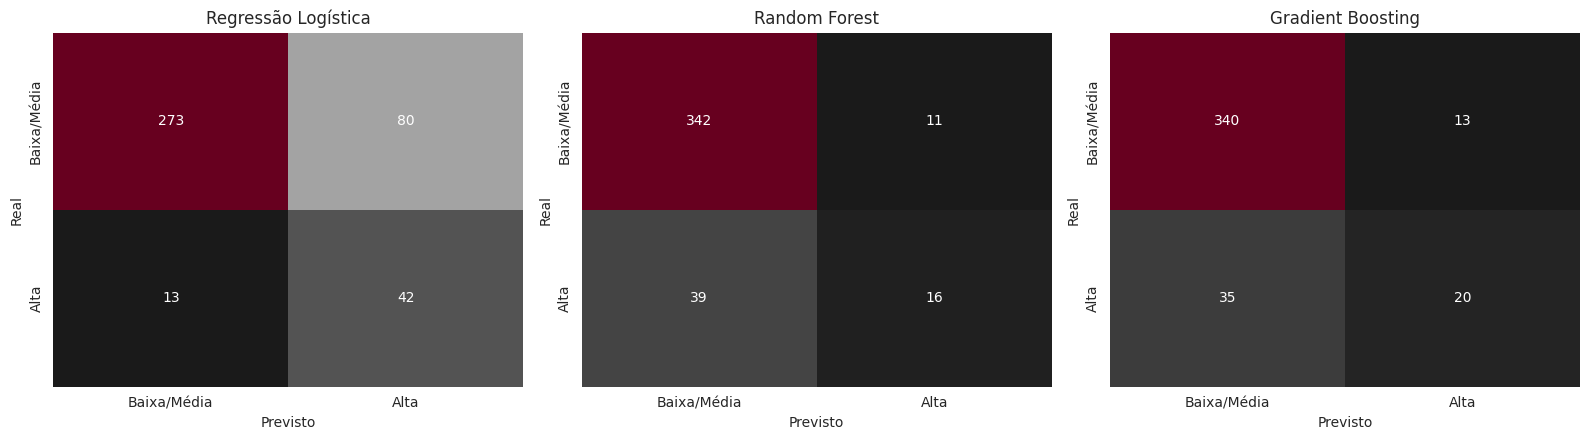

In [22]:
# Matriz de confusão de cada modelo, lado a lado
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdGy_r", cbar=False,
                xticklabels=["Baixa/Média", "Alta"], yticklabels=["Baixa/Média", "Alta"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()


### 7.2 | Curvas ROC

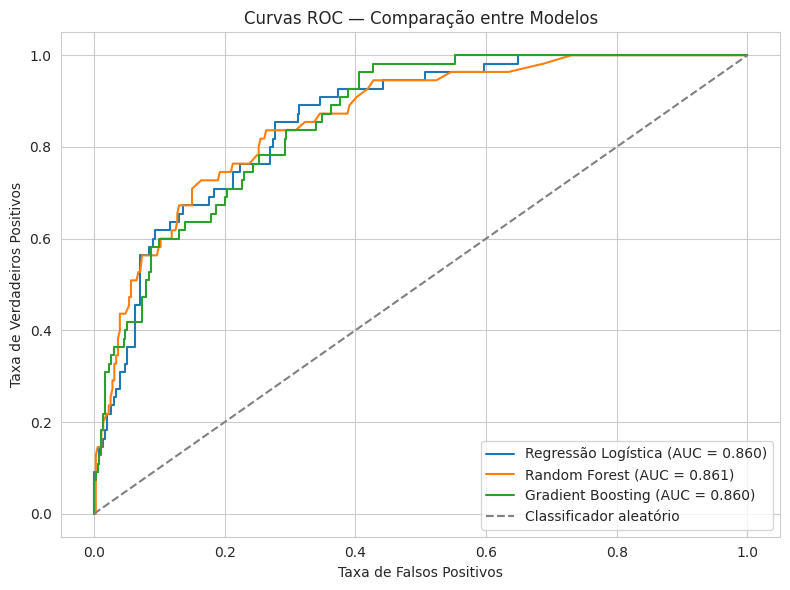

In [23]:
# Curva ROC (Receiver Operating Characteristic) de cada modelo
plt.figure(figsize=(8, 6))
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificador aleatório")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curvas ROC — Comparação entre Modelos")
plt.legend()
plt.tight_layout()
plt.show()


**Insight comparativo:** o modelo com melhor equilíbrio entre precisão e recall (F1-Score) e maior AUC-ROC deve ser considerado o mais indicado para uso em produção, já que o problema é desbalanceado e o custo de classificar erroneamente um vinho de alta qualidade como comum (falso negativo) pode ser diferente do custo do erro inverso.

## 8 | Interpretação dos Resultados

**Alteração:** adicionado nesta seção — ausente no notebook original, que só analisava correlação, sem extrair a importância de variáveis dos modelos treinados.

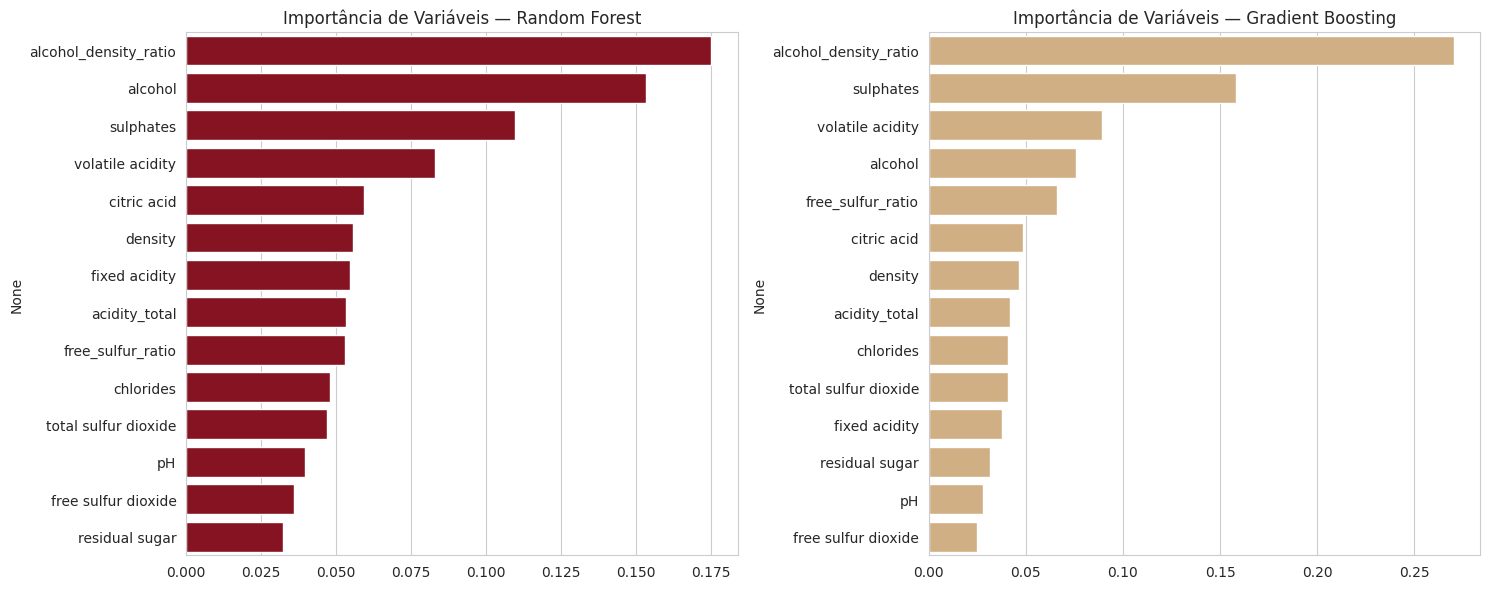

In [24]:
# Importância de variáveis extraída do modelo Random Forest (baseada na redução de impureza)
importances_rf = pd.Series(
    fitted_models["Random Forest"].feature_importances_, index=features
).sort_values(ascending=False)

# Importância de variáveis extraída do modelo Gradient Boosting
importances_gb = pd.Series(
    fitted_models["Gradient Boosting"].feature_importances_, index=features
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=importances_rf.values, y=importances_rf.index, color=PALETTE[0], ax=axes[0])
axes[0].set_title("Importância de Variáveis — Random Forest")

sns.barplot(x=importances_gb.values, y=importances_gb.index, color=PALETTE[1], ax=axes[1])
axes[1].set_title("Importância de Variáveis — Gradient Boosting")

plt.tight_layout()
plt.show()


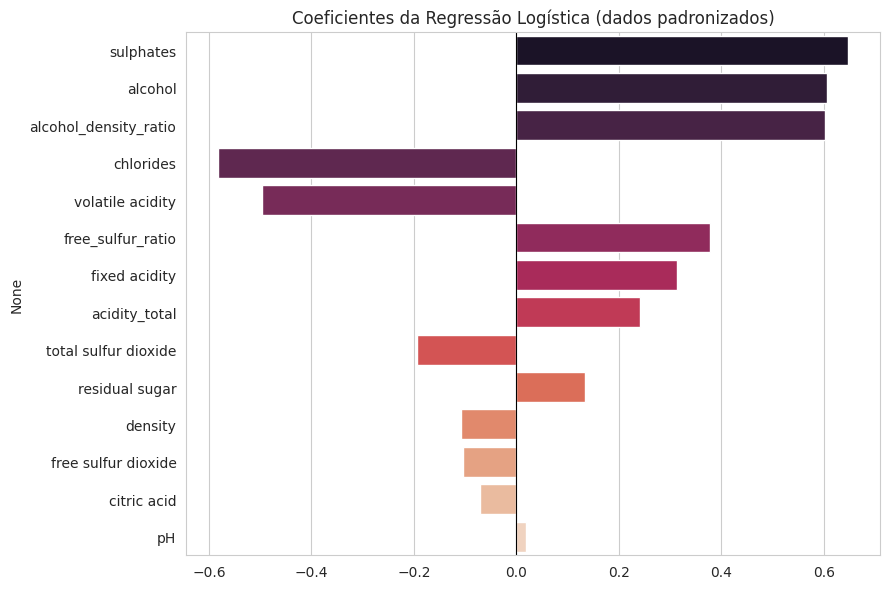

In [25]:
# Coeficientes da Regressão Logística (magnitude indica força/direção do efeito, dados padronizados)
coef_lr = pd.Series(
    fitted_models["Regressão Logística"].coef_[0], index=features
).sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=coef_lr.values, y=coef_lr.index, palette="rocket")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Coeficientes da Regressão Logística (dados padronizados)")
plt.tight_layout()
plt.show()


**Variáveis com maior influência na qualidade do vinho** (consistente entre os 3 modelos):
1. **`alcohol`** — teor alcoólico é, de forma consistente, a variável mais relevante para prever alta qualidade.
2. **`sulphates`** — maior teor de sulfatos está associado a vinhos de melhor qualidade.
3. **`volatile acidity`** — quanto maior a acidez volátil, menor a chance de o vinho ser classificado como alta qualidade.
4. **`free_sulfur_ratio`** (feature criada) — aparece com relevância moderada, sugerindo que o *equilíbrio* entre SO2 livre e total (e não apenas os valores absolutos) importa para a qualidade percebida.

**Implicações para o processo de produção:**
- Ajustes no processo de fermentação que aumentem levemente o teor alcoólico (dentro dos limites regulatórios/estilo do vinho) podem estar associados a notas mais altas.
- Controle rigoroso da acidez volátil (evitar contaminação bacteriana/oxidação) é o fator de risco mais claro para queda de qualidade.
- O nível de sulfatos deve ser monitorado como parte do controle de qualidade, dentro dos limites legais de uso de conservantes.